# 06a · GSE65391 · RNA_array · gap statistic: how many groups, if any?

Reads `modules.rds`, `wgcna_input.rds`.

**Matrix.** The same as the heatmaps (notebooks 07, 08): the 157 first visits  by  the 10 hub genes
(highest kME) of each module, each gene z-scored across patients.

**Method.** The gap statistic (Tibshirani R, Walther G, Hastie T. Estimating the number of clusters in
a data set via the gap statistic. *J R Stat Soc B* 2001;63:411-423). For each k, it compares the
within-cluster dispersion log(W_k) of the data with its expected value under a reference
distribution that has **no clusters**:

  Gap(k) = E*[log(W_k)] - log W_k

E* is estimated from B reference data sets drawn uniformly over the box aligned with the data's
principal components (`spaceH0 = "scaledPCA"`, one of the two reference distributions the paper proposes).

| setting | value | reason |
|---|---|---|
| k, patients | 1 to 8 | k = 1 is included, so "no structure" is a possible answer |
| k, genes | 1 to 20 | the genes are the hub genes of the GSE65391 modules (14 modules), so the gene axis has about 14 groups by construction; the range must extend past 14 for the answer to fall inside it |
| B | 500 reference data sets | the package default is 100; more reference sets reduce the Monte Carlo error of E*[log(W_k)] (the reported SE includes the factor the square root of (1 + 1/B)) |
| d.power | 2 | squared Euclidean distances; the `clusGap` documentation: `d.power = 2` "corresponds to what Tibshirani et al had proposed" (the default, 1, is the historical R implementation) |
| rule | `Tibs2001SEmax` | the paper's rule: the smallest k with Gap(k) ≥ Gap(k+1) - SE(k+1); it returns k = 1 when no larger k improves Gap by more than its standard error |

**Clustering method: k-means only**, on **both axes** (patients as observations; genes as
observations), 50 random starts.

**Why k-means only.** k, the number of clusters, is an input of k-means (Lloyd SP. Least squares
quantization in PCM. *IEEE Trans Inf Theory* 1982;28:129-137, doi:10.1109/TIT.1982.1056489; R's
`kmeans` uses Hartigan JA, Wong MA. Algorithm AS 136. *J R Stat Soc C* 1979;28:100-108,
doi:10.2307/2346830), so a rule for choosing k is needed and the gap statistic is such a rule. Ward's
hierarchical clustering (Ward JH. *J Am Stat Assoc* 1963;58:236-244, doi:10.1080/01621459.1963.10500845;
the `ward.D2` implementation: Murtagh F, Legendre P. *J Classif* 2014;31:274-295,
doi:10.1007/s00357-014-9161-z) has no k: its result is the whole tree. Cutting the tree at a chosen k
is an extra step the method does not make. Whether branches of the tree are supported is assessed
separately, by bootstrap (pvclust-py) and by tree shape (Dynamic Tree Cut), in their own notebooks.

The gap statistic is computed with `cluster::clusGap` (Maechler M et al., R package `cluster`),
which implements Tibshirani et al. (2001) and documents the settings below.

**Reading.** k = 1 means the data are no more clustered than the no-cluster reference.
## Build the matrix: first visits by hub genes

In [1]:
source("../src/paths.R")
suppressMessages(library(cluster))
mods <- readRDS(art("GSE65391", "modules.rds"))
w    <- readRDS(art("GSE65391", "wgcna_input.rds"))
hub  <- unlist(lapply(mods$hubs, head, 10))
X    <- scale(w$datExpr[, hub])                   # patients x genes, z-score per gene
dim(X)

[1] 157 140

**Explanation**
- `library(cluster)` loads the R package that provides `clusGap()` (Maechler M et al., R package `cluster`).
- `mods$hubs` holds, for each module, its genes ordered by kME (notebook 05). `lapply(mods$hubs, head, 10)`
  keeps the first 10 of each module; `unlist()` joins them into one list of 140 genes.
- `w$datExpr[, hub]` takes those genes for the 157 first visits.
- `scale()` z-scores each column: each gene minus its mean, divided by its SD. For example, a gene with mean
  8 and SD 2 has the value 10 turned into 1.
- `dim(X)` prints 157 rows (children) and 140 columns (genes).

## Run the gap statistic on both axes

In [2]:
km_fun   <- function(x, k) list(cluster = if (k == 1) rep(1L, nrow(x)) else kmeans(x, k, nstart = 50, iter.max = 100)$cluster)
gap_run  <- function(x, fun, K.max) { set.seed(SEED); clusGap(x, FUNcluster = fun, K.max = K.max, B = 500, d.power = 2, spaceH0 = "scaledPCA", verbose = FALSE) }
gaps <- list(
  "patients, k-means" = gap_run(X, km_fun, K.max = 8),
  "genes, k-means"    = gap_run(t(X), km_fun, K.max = 20))

**Explanation**
- `km_fun(x, k)` clusters the rows of `x` into `k` groups with k-means and returns the group of each row,
  in the form `clusGap()` expects: a list with an element named `cluster`.
  - With `k = 1` every row is in group 1: `rep(1L, nrow(x))` repeats 1 once per row.
  - Otherwise `kmeans(x, k, nstart = 50, iter.max = 100)` runs k-means from 50 random starts, up to 100
    steps each, and keeps the best result.
- `gap_run(x, fun, K.max)` runs the gap statistic for k = 1 to `K.max`, with the settings in the table above.
  `set.seed(SEED)` fixes the random reference data sets, so a second run gives the same answer.
- `gaps` holds two runs:
  - patients: the rows of `X` are the 157 children, k from 1-8;
  - genes: `t(X)` turns the matrix so that the 140 genes are the rows, k from 1 to 20.
- This cell takes about 15 minutes: 500 reference data sets, each clustered at every k.

## Gap for every k, and the k chosen

In [3]:
for (nm in names(gaps)) {
  g <- gaps[[nm]]$Tab
  print(data.frame(axis = nm, k = seq_len(nrow(g)), gap = round(g[, "gap"], 4), SE = round(g[, "SE.sim"], 4)))
}
chosen <- sapply(gaps, function(g) maxSE(g$Tab[, "gap"], g$Tab[, "SE.sim"], method = "Tibs2001SEmax"))
chosen

               axis k    gap     SE
1 patients, k-means 1 0.8578 0.0215
2 patients, k-means 2 0.8215 0.0185
3 patients, k-means 3 0.8324 0.0174
4 patients, k-means 4 0.8390 0.0168
5 patients, k-means 5 0.8427 0.0163
6 patients, k-means 6 0.8425 0.0159
7 patients, k-means 7 0.8399 0.0156
8 patients, k-means 8 0.8422 0.0154
             axis  k    gap     SE
1  genes, k-means  1 0.4521 0.0193
2  genes, k-means  2 0.5099 0.0177
3  genes, k-means  3 0.5598 0.0167
4  genes, k-means  4 0.6287 0.0157
5  genes, k-means  5 0.6969 0.0155
6  genes, k-means  6 0.7654 0.0154
7  genes, k-means  7 0.8278 0.0152
8  genes, k-means  8 0.8940 0.0148
9  genes, k-means  9 0.9650 0.0145
10 genes, k-means 10 1.0552 0.0144
11 genes, k-means 11 1.1060 0.0142
12 genes, k-means 12 1.2172 0.0142
13 genes, k-means 13 1.2987 0.0142
14 genes, k-means 14 1.3597 0.0141
15 genes, k-means 15 1.3642 0.0140
16 genes, k-means 16 1.3591 0.0139
17 genes, k-means 17 1.3588 0.0139
18 genes, k-means 18 1.3555 0.0139
19 genes, k

patients, k-means    genes, k-means 
                1                14

**Explanation**
- `for (nm in names(gaps))` runs the loop body once for each axis.
- `gaps[[nm]]$Tab` is the table `clusGap()` returns: one row per k, with the gap and its standard error
  `SE.sim`.
- `seq_len(nrow(g))` numbers the rows 1, 2, 3 and so on, which are the values of k.
- `maxSE(gap, SE, method = "Tibs2001SEmax")` applies the rule of Tibshirani et al. (2001): the smallest k
  whose gap is at least the gap at k + 1 minus its standard error. For example, if the gap at k = 1 is 1.19
  and the gap at k = 2 is 1.18 with SE 0.03, then 1.19 is at least 1.18 - 0.03, so k = 1 is chosen.

**Result.**
- **Patients: k = 1.** Gap is highest at k = 1 (0.858 plus or minus 0.022); no larger k comes within reach
  (0.822 at k = 2, 0.843 at k = 5 and 8). The 157 children at first visit are no more clustered than the
  no-cluster reference.
- **Genes: k = 14.** Gap rises from 0.452 at k = 1 to 1.360 at k = 14 and levels off (1.364 at 15, 1.356 to
  1.363 at 16 to 20). The hub genes come from 14 WGCNA modules, so the genes group as WGCNA grouped them.

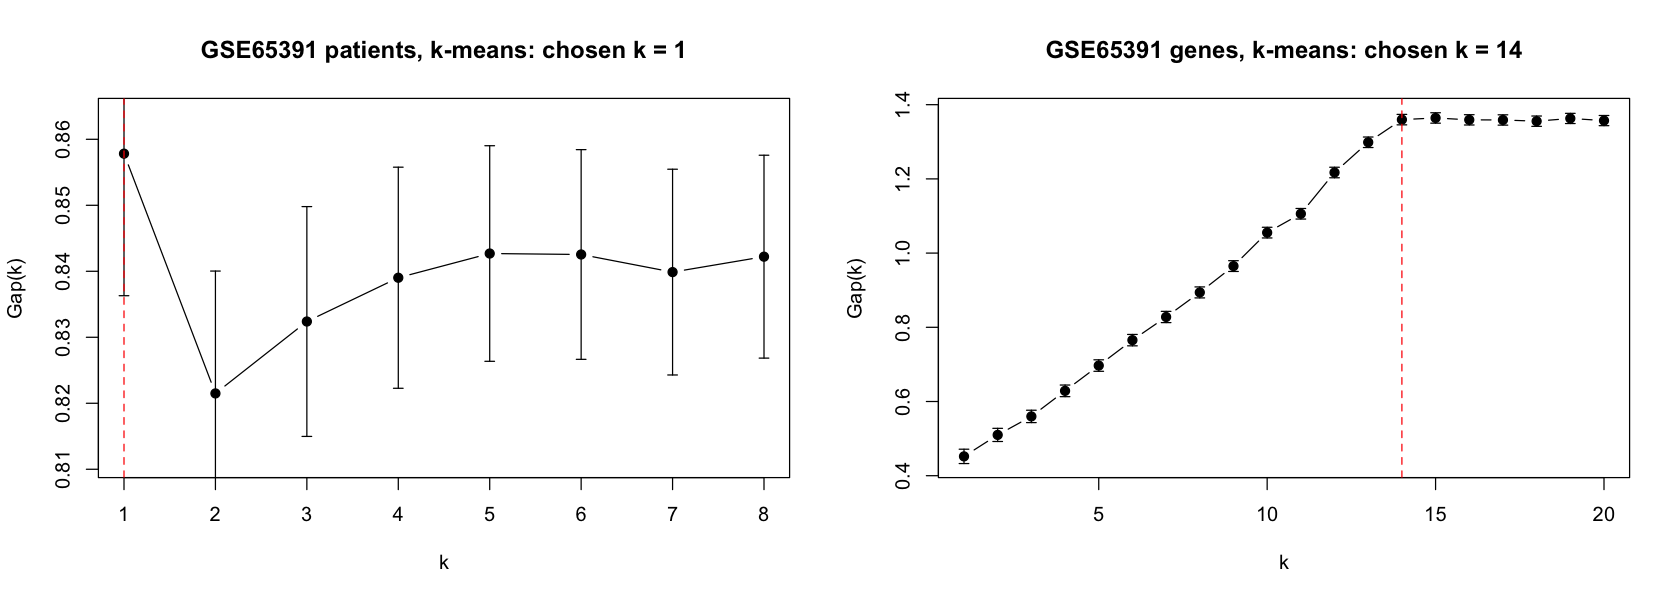

In [4]:
options(repr.plot.width = 14, repr.plot.height = 5)
figure <- function() {
  par(mfrow = c(1, 2))
  for (nm in names(gaps)) {
    g <- gaps[[nm]]$Tab
    k <- seq_len(nrow(g))
    plot(k, g[, "gap"], type = "b", pch = 19, ylim = range(g[, "gap"] + c(-1, 1) * max(g[, "SE.sim"])),
         xlab = "k", ylab = "Gap(k)", main = sprintf("GSE65391 %s: chosen k = %d", nm, chosen[[nm]]))
    arrows(k, g[, "gap"] - g[, "SE.sim"], k, g[, "gap"] + g[, "SE.sim"], angle = 90, code = 3, length = 0.04)
    abline(v = chosen[[nm]], lty = 2, col = "red")
  }
}
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("GSE65391", "06a_GSE65391_RNA_array_gap_statistic_1.png"), width = 14, height = 5, units = "in", res = 300)
  out <- figure(); if (inherits(out, c("Heatmap", "HeatmapList"))) draw(out)
  if (device == "png") invisible(dev.off())
}

**Explanation**
- One plot per axis: the gap at each k (`type = "b"` draws points joined by lines).
- `arrows(..., angle = 90, code = 3)` draws a bar from gap minus SE to gap plus SE at each k: flat ends
  (angle 90) at both ends (code 3). These are error bars, not arrows.
- `abline(v = ..., lty = 2)` draws a dashed vertical line at the chosen k.
- `sprintf("... %s ... %d", nm, k)` puts the axis name (`%s`, text) and the chosen k (`%d`, a whole number)
  into the title.
- The figure loop is explained in notebook 04.

## Save

In [5]:
saveRDS(list(gaps = gaps, chosen = chosen), art("GSE65391", "gap_statistic.rds"))

**Explanation**
- `gap_statistic.rds` keeps both runs and the chosen k. Notebook 08 reads the chosen k for its k-means
  heatmap.